# LAB-D2-01 SOLUTION: Loss Landscapes and Learning-Rate Roulette

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Objectives:** `OBJ-D2-02`, `OBJ-D2-03`  
**Reference environment:** local CPU; Python 3.11+; NumPy and matplotlib; no network or GPU  
**Expected compute runtime:** under 10 seconds  
**Execution contract:** Clear outputs, restart the kernel, and run all cells from top to bottom.

This notebook preserves the participant sequence while completing every prediction, implementation,
diagnosis, challenge, optional extension, and reflection. Expected values are reference evidence for
the supplied deterministic inputs, not transferable learning-rate rules for other objectives.

In [1]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__}")
print("Runtime target: local/Colab CPU; no network or GPU required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1
Runtime target: local/Colab CPU; no network or GPU required.


## Recap: From a Forward Pass to an Update

Day 1 ended at a prediction. Training adds an error signal and an update:

$$w_{next}=w-\eta\frac{\partial L}{\partial w}$$

The gradient supplies direction and local sensitivity. The learning rate $\eta$ scales that proposed change. In this lab, loss is evidence for optimization; thresholded accuracy remains a separate evaluation summary.

## Local Dataset: Four Equal-Length BCE Cases

All four cases use targets `y = [1, 0, 1, 0]`. Their probability vectors are generated below, so there is no file or cross-notebook state. Classes use the explicit rule `p >= 0.5`.

In [2]:
targets = np.array([1.0, 0.0, 1.0, 0.0])
bce_cases = {
    "A": np.array([0.90, 0.10, 0.80, 0.20]),
    "B": np.array([0.55, 0.45, 0.60, 0.40]),
    "C": np.array([0.90, 0.10, 0.49, 0.20]),
    "D": np.array([0.90, 0.10, 0.01, 0.20]),
}
assert targets.shape == (4,)
assert all(values.shape == targets.shape for values in bce_cases.values())
assert all(np.all((0.0 <= values) & (values <= 1.0)) for values in bce_cases.values())
print("Local BCE cases ready:", list(bce_cases))

Local BCE cases ready: ['A', 'B', 'C', 'D']


## Predict Before Calculating BCE

Rank cases `A` through `D` from lowest to highest expected BCE. Record the thresholded accuracy you expect for each case. Then identify one comparison that best exposes information discarded by thresholding. Preserve this commitment when the values appear.

### Instructor Hint Ladder: BCE Ranking

Use these in order before showing the completed prediction: (1) threshold each vector first;
(2) compare correct probabilities by distance from the correct endpoint; (3) isolate pairs with the
same class decisions; (4) ask which wrong probability is nearest zero for a positive target.

**Likely misconception:** Accuracy and BCE must rank cases identically. Accuracy sees only the side
of `0.5`; BCE retains probability information.

In [3]:
bce_predictions = {
    "ranking_low_to_high": "A, C, B, D",
    "accuracy_A": "1.00",
    "accuracy_B": "1.00",
    "accuracy_C": "0.75",
    "accuracy_D": "0.75",
    "most_informative_comparison": "C versus D",
    "reason": "C and D make the same thresholded decisions, but D assigns 0.01 to a positive target, so BCE penalizes its much stronger wrong probability.",
}
assert all(value.strip() for value in bce_predictions.values()), (
    "Prediction checkpoint: complete every BCE field before calculating loss."
)
print("Instructor prediction:", bce_predictions)

Instructor prediction: {'ranking_low_to_high': 'A, C, B, D', 'accuracy_A': '1.00', 'accuracy_B': '1.00', 'accuracy_C': '0.75', 'accuracy_D': '0.75', 'most_informative_comparison': 'C versus D', 'reason': 'C and D make the same thresholded decisions, but D assigns 0.01 to a positive target, so BCE penalizes its much stronger wrong probability.'}


## Modify: Implement Clipped Binary Cross-Entropy

Complete `binary_cross_entropy`. Convert inputs to arrays, clip probabilities to `[epsilon, 1 - epsilon]`, and return the mean per-example BCE. The function must remain finite when supplied probabilities include exact `0` or `1`.

In [4]:
def binary_cross_entropy(y_true, probabilities, epsilon=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    clipped = np.clip(probabilities, epsilon, 1.0 - epsilon)
    return float(np.mean(-(y_true * np.log(clipped) + (1.0 - y_true) * np.log(1.0 - clipped))))

In [5]:
bce_results = {}
print(f"{'case':<6} {'accuracy':>10} {'BCE':>12}")
for name, probabilities in bce_cases.items():
    predictions = (probabilities >= 0.5).astype(int)
    accuracy = float(np.mean(predictions == targets))
    loss = binary_cross_entropy(targets, probabilities)
    bce_results[name] = {"accuracy": accuracy, "loss": loss}
    print(f"{name:<6} {accuracy:>10.2f} {loss:>12.6f}")
assert all(np.isfinite(result['loss']) and result['loss'] >= 0.0 for result in bce_results.values())

case     accuracy          BCE
A            1.00     0.164252
B            1.00     0.554331
C            0.75     0.286804
D            0.75     1.259759


### Instructor Reveal: Expected BCE Evidence

The clean reference values are approximately A `0.1643`, C `0.2868`, B `0.5543`, and D `1.2598`.
The useful discussion is not memorizing these values; it is identifying why equal accuracy permits
different loss. A vectorized implementation, a per-example-then-mean implementation, or use of
`np.log1p(-p)` are acceptable when clipping and reduction are correct.

## Break It Safely: Exact Extreme Probabilities

A hand-written BCE without clipping evaluates logarithms at exact endpoints. Before running the next cell, predict whether the naive result will be finite and state why clipping is a numerical safeguard rather than a claim that the extreme prediction was good.

### Instructor Hint Ladder: Endpoint Failure

(1) Substitute the endpoint probabilities into both logarithms. (2) Identify every `log(0)` term.
(3) Separate numerical finiteness from prediction quality. Reveal only after participants commit.

In [6]:
extreme_prediction = {
    "naive_finite": "No. log(0) appears for both confidently wrong endpoint predictions, so the mean is infinite.",
    "clipping_interpretation": "Clipping prevents undefined logarithms; it still leaves a very large loss and does not relabel a bad prediction as acceptable.",
}
assert all(value.strip() for value in extreme_prediction.values()), (
    "Prediction checkpoint: commit to the extreme-probability behavior first."
)
print("Instructor prediction:", extreme_prediction)

Instructor prediction: {'naive_finite': 'No. log(0) appears for both confidently wrong endpoint predictions, so the mean is infinite.', 'clipping_interpretation': 'Clipping prevents undefined logarithms; it still leaves a very large loss and does not relabel a bad prediction as acceptable.'}


In [7]:
extreme_targets = np.array([1.0, 0.0])
extreme_probabilities = np.array([0.0, 1.0])
with np.errstate(divide='ignore', invalid='ignore'):
    naive_terms = -(extreme_targets * np.log(extreme_probabilities) + (1.0 - extreme_targets) * np.log(1.0 - extreme_probabilities))
    naive_loss = float(np.mean(naive_terms))
stable_extreme_loss = binary_cross_entropy(extreme_targets, extreme_probabilities)
print("Naive extreme BCE:", naive_loss)
print("Clipped extreme BCE:", stable_extreme_loss)
assert not np.isfinite(naive_loss)
assert np.isfinite(stable_extreme_loss) and stable_extreme_loss > 0.0

Naive extreme BCE: inf
Clipped extreme BCE: 27.631032176910953


## Observe: A Deterministic One-Parameter Landscape

Use $L(w)=(w-3)^2$, whose minimum is at `w = 3`. Every run starts at `w = -1` and uses 12 updates. This landscape is a teaching instrument: its numeric learning-rate regimes do not transfer unchanged to other objectives.

## Predict the Four Trajectories

For learning rates `0.01`, `0.10`, `0.90`, and `1.10`, classify the expected path as crawl, smooth convergence, oscillatory convergence, or divergence. Sketch the first three sides/positions relative to `w = 3`, and name the observation that distinguishes shrinking oscillation from divergence.

### Instructor Hint Ladder: Trajectory Cards

(1) Compute the initial gradient at `w=-1`. (2) Calculate only the first update for each card.
(3) Rewrite the error as `e = w - 3`. (4) Derive `e_next = (1 - 2*eta)e` and classify the sign and
magnitude of the multiplier. **Wrong answer to surface:** Every oscillating path diverges.

In [8]:
learning_rates = [0.01, 0.10, 0.90, 1.10]
trajectory_predictions = {
    "0.01": "Crawl on the starting side; multiplier 0.98 contracts distance slowly.",
    "0.10": "Smooth convergence without crossing; multiplier 0.80.",
    "0.90": "Oscillatory convergence; multiplier -0.80 crosses each step while shrinking.",
    "1.10": "Divergence; multiplier -1.20 crosses each step while distance grows.",
    "first_three_step_sketch": "eta 0.01: -0.92, -0.8416, -0.7648; eta 0.10: -0.20, 0.44, 0.952; eta 0.90: 6.20, 0.44, 5.048; eta 1.10: 7.80, -2.76, 9.912.",
    "oscillation_vs_divergence_check": "Track |w - 3| across crossings: shrinking distance is convergence; growing distance is divergence.",
}
assert all(value.strip() for value in trajectory_predictions.values()), (
    "Prediction checkpoint: classify and sketch every path before running updates."
)
print("Instructor trajectory predictions recorded.")

Instructor trajectory predictions recorded.


## Modify: Implement Gradient, Update, and Recorder

Complete the three TODOs. A trajectory dictionary must include arrays named `position`, `loss`, and `distance`, each of length `steps + 1` so the starting state remains visible.

In [9]:
OPTIMUM = 3.0
START = -1.0
STEPS = 12

def quadratic_loss(position):
    return (position - OPTIMUM) ** 2

def quadratic_gradient(position):
    return 2.0 * (position - OPTIMUM)

def gradient_step(position, learning_rate):
    return position - learning_rate * quadratic_gradient(position)

def record_trajectory(start, learning_rate, steps):
    positions = [float(start)]
    for _ in range(steps):
        positions.append(gradient_step(positions[-1], learning_rate))
    positions = np.asarray(positions, dtype=float)
    return {
        "position": positions,
        "loss": np.asarray([quadratic_loss(position) for position in positions]),
        "distance": np.abs(positions - OPTIMUM),
    }

In [10]:
trajectories = {rate: record_trajectory(START, rate, STEPS) for rate in learning_rates}
print(f"{'eta':>6} {'first w':>10} {'last w':>12} {'last loss':>14} {'last distance':>16}")
for rate, trace in trajectories.items():
    assert set(trace) == {"position", "loss", "distance"}
    assert all(np.asarray(trace[name]).shape == (STEPS + 1,) for name in trace)
    print(f"{rate:>6.2f} {trace['position'][1]:>10.4f} {trace['position'][-1]:>12.4f} {trace['loss'][-1]:>14.6f} {trace['distance'][-1]:>16.6f}")

   eta    first w       last w      last loss    last distance
  0.01    -0.9200      -0.1389       9.852485         3.138867
  0.10    -0.2000       2.7251       0.075558         0.274878
  0.90     6.2000       2.7251       0.075558         0.274878
  1.10     7.8000     -32.6644    1271.949555        35.664402


### Instructor Reveal: Calibrated Path Evidence

After 12 updates, expected distances are about `3.139` (`eta=0.01`), `0.2749` (`0.10`),
`0.2749` (`0.90`), and `35.664` (`1.10`). The equal final distances for `0.10` and `0.90`
hide opposite path geometry, which is why the position trace matters.

**Fast recovery:** If live plotting fails, use the printed first/last positions and distances; these
are sufficient to classify all four paths.

## Inspect: Position, Loss, and Distance on Aligned Steps

All panels share the same update axis. Position reveals side-crossing, loss shows optimization progress, and distance distinguishes shrinking from expanding oscillation. The loss/distance panels use logarithmic vertical scales so the divergent path does not flatten every other trace.

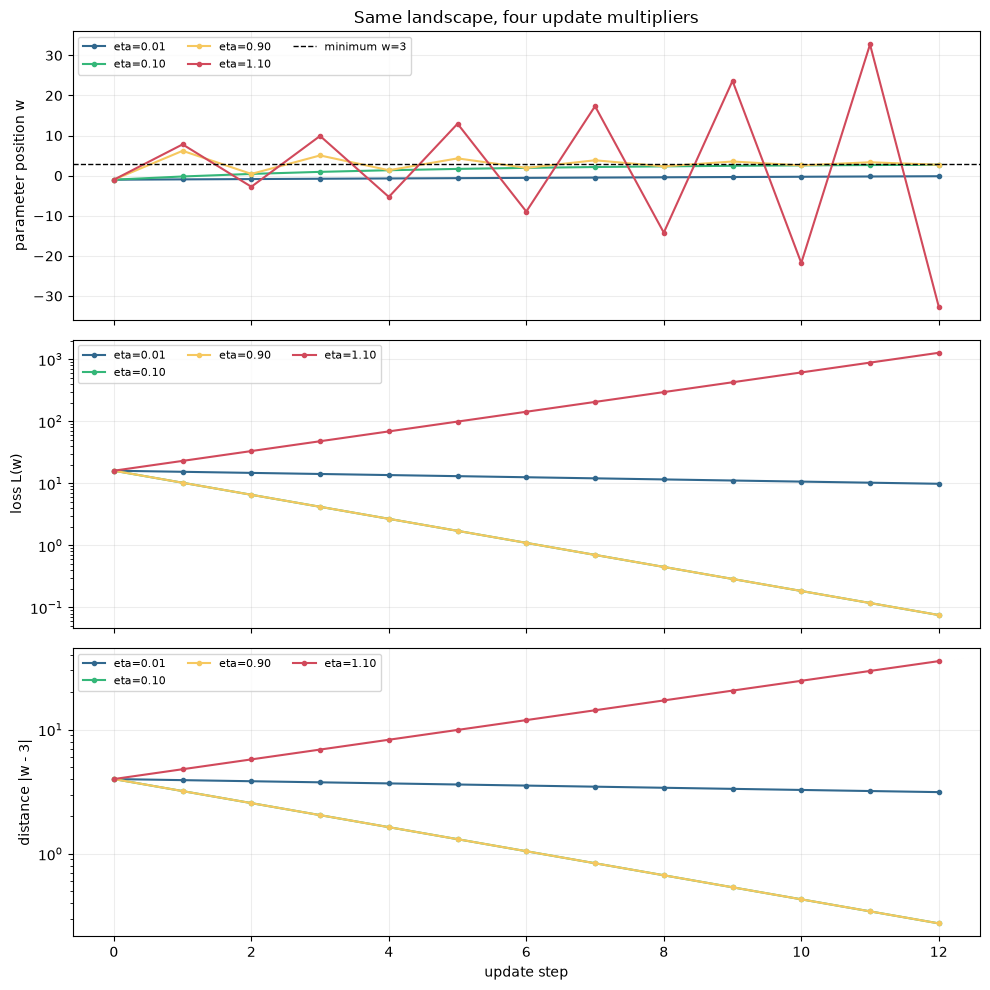

In [11]:
colors = {0.01: "#31688e", 0.10: "#35b779", 0.90: "#f6c85f", 1.10: "#d1495b"}
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
step_axis = np.arange(STEPS + 1)
for rate, trace in trajectories.items():
    label = f"eta={rate:.2f}"
    axes[0].plot(step_axis, trace['position'], marker='o', markersize=3, color=colors[rate], label=label)
    axes[1].plot(step_axis, trace['loss'], marker='o', markersize=3, color=colors[rate], label=label)
    axes[2].plot(step_axis, trace['distance'], marker='o', markersize=3, color=colors[rate], label=label)
axes[0].axhline(OPTIMUM, color='black', linestyle='--', linewidth=1, label='minimum w=3')
axes[0].set(ylabel='parameter position w', title='Same landscape, four update multipliers')
axes[1].set(ylabel='loss L(w)', yscale='log')
axes[2].set(xlabel='update step', ylabel='distance |w - 3|', yscale='log')
for ax in axes:
    ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## Diagnose and Explain the Update Mechanism

For each rate, cite position and distance evidence, then explain the movement using the sign and magnitude of `learning_rate * gradient`. Derive the one-step distance multiplier for this specific quadratic. State why the last loss alone is insufficient to reconstruct every path.

In [12]:
trajectory_interpretation = {
    "0.01_evidence_and_mechanism": "Distance falls only from 4.0 to about 3.14. The gradient points right, but eta scales it to a small step and the positive 0.98 multiplier keeps every point on the same side.",
    "0.10_evidence_and_mechanism": "Position approaches 3 without crossing and loss falls to about 0.0756. The 0.80 multiplier contracts distance by 20% per update.",
    "0.90_evidence_and_mechanism": "The path crosses 3 every step while distance falls to about 0.275. The negative -0.80 multiplier flips side and contracts magnitude.",
    "1.10_evidence_and_mechanism": "The path crosses every step while distance grows to about 35.66 and loss exceeds 1,200. The -1.20 multiplier flips side and expands magnitude.",
    "distance_multiplier_derivation": "Let e=w-3. Then e_next=e-eta(2e)=(1-2eta)e, so distance is multiplied by |1-2eta|.",
    "last_loss_limit": "A final scalar does not show side-crossings, monotonicity, or whether instability occurred earlier; the trajectory carries those distinctions.",
}
assert all(value.strip() for value in trajectory_interpretation.values()), (
    "Diagnosis checkpoint: complete every evidence-and-mechanism field."
)
print("Instructor mechanism derivation:", trajectory_interpretation["distance_multiplier_derivation"])

Instructor mechanism derivation: Let e=w-3. Then e_next=e-eta(2e)=(1-2eta)e, so distance is multiplied by |1-2eta|.


## Challenge: Predict One New Rate Without a Sweep

Choose one rate in `(0, 1.2)` that is not already present. Use your distance-multiplier derivation to predict the first position, whether side-crossing occurs, and whether distance contracts over six steps. You get one run after committing.

### Instructor Hint Ladder: One-Shot Challenge

Require the multiplier calculation before allowing execution. Rates on either side of `0.5` can be
valid choices; assess whether the prediction follows from `1 - 2*eta`, not whether it matches the
reference choice `0.60`.

In [13]:
challenge_rate = 0.60
challenge_prediction = {
    "first_position": "3.8 because -1 - 0.60(-8) = 3.8.",
    "side_crossing": "Yes. The multiplier is -0.20, so every nonzero error changes sign.",
    "six_step_distance_behavior": "Distance contracts by a factor of 0.20 per step: 4.0, 0.8, 0.16, ...",
}
assert challenge_rate is not None and 0.0 < float(challenge_rate) < 1.2
assert not any(np.isclose(float(challenge_rate), rate) for rate in learning_rates)
assert all(value.strip() for value in challenge_prediction.values())
print("Instructor challenge prediction:", challenge_prediction)

Instructor challenge prediction: {'first_position': '3.8 because -1 - 0.60(-8) = 3.8.', 'side_crossing': 'Yes. The multiplier is -0.20, so every nonzero error changes sign.', 'six_step_distance_behavior': 'Distance contracts by a factor of 0.20 per step: 4.0, 0.8, 0.16, ...'}


In [14]:
challenge_trace = record_trajectory(START, float(challenge_rate), 6)
print("Challenge positions:", np.round(challenge_trace['position'], 4))
print("Challenge distances:", np.round(challenge_trace['distance'], 4))
challenge_interpretation = (
    "The run matches all three predictions: the first position is 3.8, each step crosses the optimum, "
    "and distance contracts by approximately 0.20 per update."
)
assert challenge_interpretation.strip()
print("Instructor interpretation:", challenge_interpretation)

Challenge positions: [-1.      3.8     2.84    3.032   2.9936  3.0013  2.9997]
Challenge distances: [4.     0.8    0.16   0.032  0.0064 0.0013 0.0003]
Instructor interpretation: The run matches all three predictions: the first position is 3.8, each step crosses the optimum, and distance contracts by approximately 0.20 per update.


## Optional Extension: Change Curvature, Keep the Rate

Replace the landscape with $L_c(w)=c(w-3)^2$ for one positive curvature scale `c`. Before running, predict how the same learning rate changes its effective update multiplier. This extension is not required by the core checkpoint.

In [15]:
optional_curvature = 2.0
optional_rate = 0.60
optional_prediction = "The multiplier becomes 1 - 2*eta*c = -1.4, so the path will cross and expand."
if optional_curvature is None or optional_rate is None or not optional_prediction.strip():
    print("Optional extension skipped. Core checkpoint is unaffected.")
else:
    assert optional_curvature > 0.0 and not np.isclose(optional_curvature, 1.0)
    optional_positions = [START]
    for _ in range(8):
        gradient = 2.0 * optional_curvature * (optional_positions[-1] - OPTIMUM)
        optional_positions.append(optional_positions[-1] - optional_rate * gradient)
    optional_positions = np.asarray(optional_positions)
    optional_distances = np.abs(optional_positions - OPTIMUM)
    print("Optional positions:", np.round(optional_positions, 4))
    print("Optional distances:", np.round(optional_distances, 4))
    optional_interpretation = "Evidence matches the -1.4 multiplier: signs alternate and distances grow by a factor of about 1.4."
    assert optional_interpretation.strip()
    print("Instructor interpretation:", optional_interpretation)

Optional positions: [ -1.       8.6     -4.84    13.976  -12.3664  24.513  -27.1181  45.1654
 -56.0316]
Optional distances: [ 4.      5.6     7.84   10.976  15.3664 21.513  30.1181 42.1654 59.0316]
Instructor interpretation: Evidence matches the -1.4 multiplier: signs alternate and distances grow by a factor of about 1.4.


## Reflect and Checkpoint

Complete the evidence record. Distinguish what accuracy omitted, what clipping changed numerically, and how update sign/magnitude produced each path. Name one reason these learning-rate thresholds are local to this quadratic.

### Instructor Debrief and Delivery Notes

**Discussion triggers:** Which evidence distinguishes optimization behavior from endpoint arithmetic?
Why do `eta=0.10` and `eta=0.90` share a final distance but tell different stories? What changes when
curvature changes?

**Runtime/order failures:** An undefined trajectory means the implementation cell was skipped. A
12-element trace omitted the starting state. A hidden divergent curve usually means linear scaling
replaced the supplied log scale. CPU and Colab should produce the same deterministic values within
ordinary floating-point display precision; no accelerator helps this tiny workload.

**Acceptable alternatives:** Any challenge rate in `(0,1.2)` outside the four cards is valid with a
correct prediction. Any positive non-unit curvature and rate are valid for the optional extension
when the derived multiplier and interpretation agree.

In [16]:
reflection = {
    "loss_vs_accuracy": "Thresholded accuracy discarded probability quality: A/B and C/D tie in accuracy while BCE separates them.",
    "clipping_effect": "Clipping changed endpoint arithmetic from infinite to finite without changing the fact that the predictions are severely wrong.",
    "update_mechanism": "The gradient sets local direction and sensitivity; eta creates multiplier 1-2eta, whose sign controls crossing and magnitude controls contraction or expansion.",
    "transfer_limit": "The thresholds depend on this objective's curvature. A different loss scale, parameterization, or local geometry changes the useful eta range.",
}
assert all(value.strip() for value in reflection.values())
assert np.isfinite(stable_extreme_loss)
assert trajectories[0.01]['distance'][-1] < trajectories[0.01]['distance'][0]
assert trajectories[0.10]['loss'][-1] < trajectories[0.10]['loss'][0]
assert trajectories[0.90]['distance'][-1] < trajectories[0.90]['distance'][0]
assert trajectories[1.10]['distance'][-1] > trajectories[1.10]['distance'][0]
assert np.all(np.sign(trajectories[0.90]['position'][:-1] - OPTIMUM) != np.sign(trajectories[0.90]['position'][1:] - OPTIMUM))
print("LAB-D2-01 checkpoint passed: finite BCE, deterministic paths, aligned evidence, and update-mechanism reflection.")

LAB-D2-01 checkpoint passed: finite BCE, deterministic paths, aligned evidence, and update-mechanism reflection.


## Takeaways

- BCE responds to probability quality even when thresholded accuracy ties.
- Clipping keeps a hand-written log loss finite at endpoint probabilities; it does not make a poor prediction acceptable.
- The gradient supplies local direction and sensitivity; the learning rate scales the update.
- Oscillation can contract or expand, so side-crossing alone does not diagnose divergence.
- A trajectory is stronger diagnostic evidence than one final scalar.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| BCE is `inf` or `nan` | Logarithm received an endpoint probability | Clip before taking either logarithm |
| Every trajectory is smooth | Gradient or update sign is wrong | Print the first gradient and compare `w - eta * gradient` |
| The `0.90` path does not cross the minimum | The quadratic derivative is missing its factor of two | Differentiate the supplied loss again |
| Arrays have only 12 values | Starting state was not recorded | Store the start, then append 12 updates |
| Plot hides three paths | Divergence controls a linear axis | Keep aligned steps and use the supplied log/symlog scales |
| Results differ after rerunning cells | A supplied constant or trajectory was mutated | Restart the kernel and run from the top |

## Continue

Return to the [LAB-D2-01 debrief](../student-guide/day-2-student-guide.md#lab-d2-01---loss-landscapes-and-learning-rate-roulette). Review [LESSON-D2-01](../student-guide/day-2-student-guide.md#lesson-d2-01---the-complete-learning-loop), [LESSON-D2-02](../student-guide/day-2-student-guide.md#lesson-d2-02---loss-gradient-descent-and-learning-rate), and [ACT-D2-01](../challenges/day-2-challenges.md#act-d2-01---loss-ranking-same-accuracy-different-signal) as needed. Environment and notation conventions are in the [shared environment](../../shared/environment.md) and [notation contract](../../shared/notation-and-style.md).